Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Expression_Genes_DESeq_NPC.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\DEA_Genes_DESeq_NPC.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Clinical_Data_Rodrigues20.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,NPC_RTT_rep1,NPC_RTT_rep2,NPC_RTT_rep3,NPC_WT_rep1,NPC_WT_rep2
0,DDX11L2,84,69,126,120,80
1,WASH7P,394,529,468,424,462
2,MIR1302-2HG,4,10,12,3,8
3,ENSG00000238009,13,24,17,14,15
4,ENSG00000268903,29,15,8,10,16


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df = dea_df.rename(columns={'Unnamed: 0': 'Gene'})
dea_df = dea_df.dropna(subset=['padj'])
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,CLEC2A,12129.064280,-11.599882,0.339862,-34.131142,2.547013e-255,5.641124e-251
1,YPEL3-DT,1795.540121,-7.158766,0.256503,-27.909048,2.072083e-171,2.294625e-167
2,LHFPL3,3587.035828,5.350559,0.226581,23.614382,2.742906e-123,2.024996e-119
3,PKIB,3352.314192,6.321023,0.296990,21.283625,1.610001e-100,8.914574e-97
4,NFIA,4475.505638,5.502138,0.269725,20.399080,1.703925e-92,7.547707e-89


Volcano plot

Classification
Non-significant    20543
Up-regulated         888
Down-regulated       717
Name: count, dtype: int64
1605
Total tes:
22586


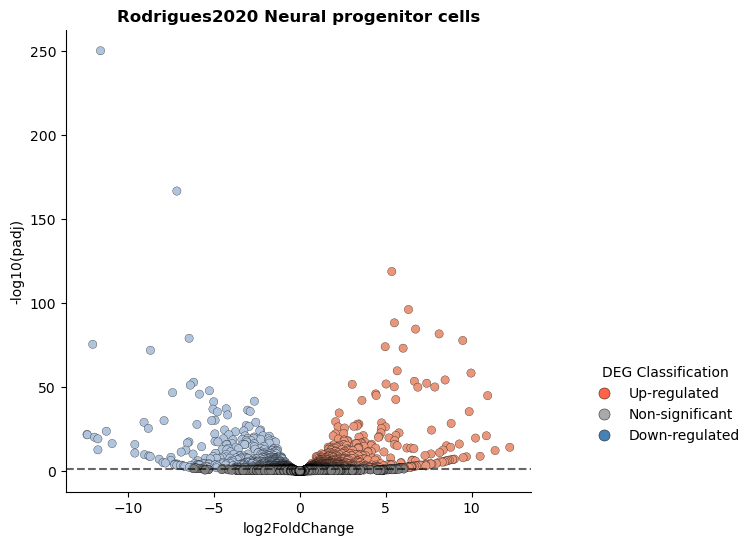

In [13]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Rodrigues2020 Neural progenitor cells', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    top_up = dea_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = dea_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data Frame

In [14]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA, sep = ";")

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())
# Process clinical data
print(clinical_data.columns)
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
print(pca_df.head())
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df.head()




   NPC_RTT_rep1  NPC_RTT_rep2  NPC_RTT_rep3  NPC_WT_rep1  NPC_WT_rep2
0      1.354823      1.052356      1.508236     1.571061     1.266119
1      3.054180      3.206853      2.972959     2.993678     3.188189
2      0.103228      0.208692      0.233493     0.069401     0.189684
3      0.311580      0.457894      0.320632     0.298631     0.337383
4      0.620833      0.302710      0.159783     0.219425     0.357301
Index(['Run', 'Cells', 'Cells_Abv', 'Sample_Description', 'Condition',
       'Sample_Name'],
      dtype='object')
    Sample_Name         PC1         PC2
0  NPC_RTT_rep1   66.793591  -78.670149
1  NPC_RTT_rep2  -84.401766  -94.946553
2  NPC_RTT_rep3  103.238148  -15.106664
3   NPC_WT_rep1   42.771766  134.559360
4   NPC_WT_rep2 -128.401739   54.164005


,Sample_Name,PC1,PC2,Condition,Run
0,NPC_RTT_rep1,66.793591,-78.670149,RTT,SRR8314928
1,NPC_RTT_rep1,66.793591,-78.670149,RTT,SRR8314929
2,NPC_RTT_rep1,66.793591,-78.670149,RTT,SRR8314930
3,NPC_RTT_rep2,-84.401766,-94.946553,RTT,SRR8314958
4,NPC_RTT_rep3,103.238148,-15.106664,RTT,SRR8314980


PCA - Graph

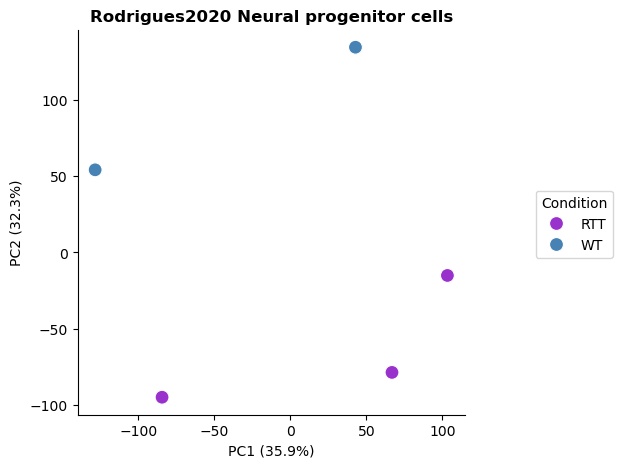

In [15]:
# Create figure
fig, ax = plt.subplots(figsize = (5,5))

palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, 
                hue = 'Condition', s = 100)


# Set labels and chart legend
ax.set_title('Rodrigues2020 Neural progenitor cells', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()

Boxplot

    Sample_Name Condition         Run
0   NPC_WT_rep1        WT  SRR8314922
1   NPC_WT_rep1        WT  SRR8314923
2   NPC_WT_rep1        WT  SRR8314924
3  NPC_RTT_rep1       RTT  SRR8314928
4  NPC_RTT_rep1       RTT  SRR8314929


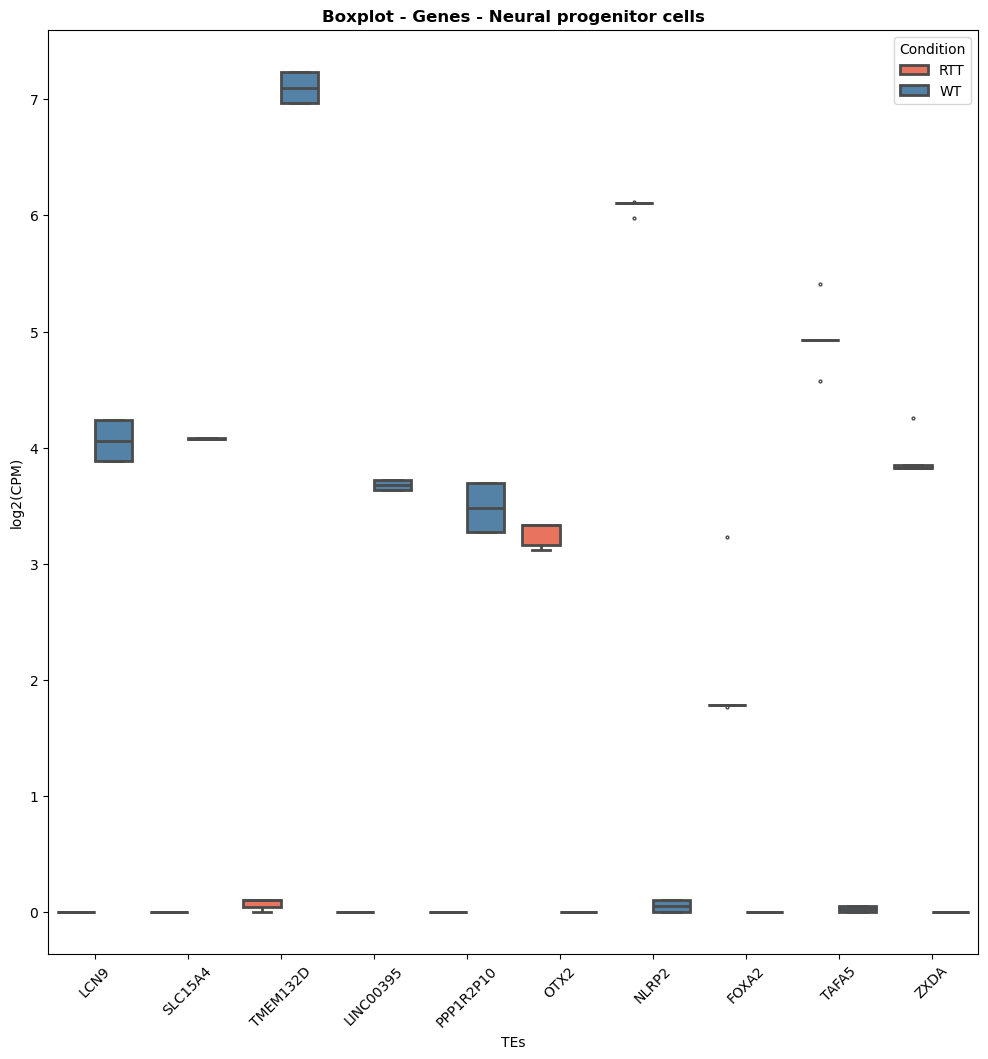

In [16]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Neural progenitor cells', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)

